In [ ]:
!pip -q install --no-cache-dir pandas numpy scipy scikit-learn matplotlib seaborn
!pip -q install --no-cache-dir torch torch-geometric
!pip -q install --no-cache-dir tensorflow==2.19.1 tf-keras

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import GCNConv, GATConv, HANConv

import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
PyTorch: 2.10.0+cu128
TensorFlow: 2.19.1


In [ ]:
DATA_DIR = Path.cwd()
REPO_DIR = Path.cwd() / "DGFraud-TF2"

if not REPO_DIR.exists():
    !git clone https://github.com/safe-graph/DGFraud-TF2.git

import sys
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

print("Data files found:",
      (DATA_DIR / "elliptic_txs_features.csv").exists(),
      (DATA_DIR / "elliptic_txs_edgelist.csv").exists(),
      (DATA_DIR / "elliptic_txs_classes.csv").exists())

Data files found: True True True


In [ ]:
cd DGFraud-TF2

[Errno 2] No such file or directory: 'DGFraud-TF2'
/content/DGFraud-TF2


In [ ]:
SEED = 42
SAMPLE_SIZE = 3000
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def load_elliptic_common(data_dir: Path, sample_size: int = 3000, seed: int = 42):
    features_df = pd.read_csv("elliptic_txs_features.csv", header=None)
    edges_df = pd.read_csv("elliptic_txs_edgelist.csv")
    classes_df = pd.read_csv("elliptic_txs_classes.csv")

    tx_ids_all = features_df[0].astype(int).values
    X_all = features_df.iloc[:, 2:].astype(float).values
    X_all[np.isinf(X_all)] = np.nan
    X_all = np.nan_to_num(X_all, nan=0.0)

    scaler = StandardScaler()
    X_all = scaler.fit_transform(X_all)
    X_all = np.nan_to_num(X_all, nan=0.0).astype(np.float32)

    classes_df = classes_df.copy()
    classes_df["class"] = classes_df["class"].astype(str)
    classes_df = classes_df[classes_df["class"].isin(["1", "2"])].copy()
    classes_df["class"] = classes_df["class"].map({"1": 1, "2": 0}).astype(int)

    label_map = dict(zip(classes_df["txId"].astype(int), classes_df["class"].astype(int)))
    y_all = np.array([label_map.get(tx, -1) for tx in tx_ids_all], dtype=np.int64)

    labeled_mask = y_all != -1
    tx_ids = tx_ids_all[labeled_mask]
    X = X_all[labeled_mask]
    y = y_all[labeled_mask]

    if sample_size < len(y):
        sample_idx, _ = train_test_split(
            np.arange(len(y)),
            train_size=sample_size,
            stratify=y,
            random_state=seed,
        )
        sample_idx = np.array(sample_idx, dtype=np.int64)
    else:
        sample_idx = np.arange(len(y), dtype=np.int64)

    tx_ids = tx_ids[sample_idx]
    X = X[sample_idx]
    y = y[sample_idx]

    txid_to_idx = {int(tx): i for i, tx in enumerate(tx_ids)}

    edges_df = edges_df.copy()
    edges_df["txId1"] = edges_df["txId1"].astype(int)
    edges_df["txId2"] = edges_df["txId2"].astype(int)

    src_idx = edges_df["txId1"].map(txid_to_idx)
    dst_idx = edges_df["txId2"].map(txid_to_idx)
    valid = (~src_idx.isna()) & (~dst_idx.isna())

    edge_pairs = np.vstack([
        src_idx[valid].astype(int).values,
        dst_idx[valid].astype(int).values,
    ])

    rev_pairs = edge_pairs[::-1]
    edge_pairs = np.concatenate([edge_pairs, rev_pairs], axis=1)

    edge_index = torch.tensor(edge_pairs, dtype=torch.long)

    n = len(y)
    adj = sp.coo_matrix(
        (np.ones(edge_index.shape[1], dtype=np.float32),
         (edge_index[0].numpy(), edge_index[1].numpy())),
        shape=(n, n),
        dtype=np.float32,
    ).tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()

    return {
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "tx_ids": tx_ids,
        "edge_index": edge_index,
        "adj": adj,
        "dataframes": (features_df, edges_df, classes_df),
    }

base = load_elliptic_common(DATA_DIR, sample_size=SAMPLE_SIZE, seed=SEED)
X = base["X"]
y = base["y"]
edge_index = base["edge_index"]
adj = base["adj"]

print("Common sample shape:", X.shape, y.shape)
print("Edge index shape:", edge_index.shape)
print("Adj shape:", adj.shape)
print("Class balance:", np.bincount(y))

Device: cuda
Common sample shape: (3000, 165) (3000,)
Edge index shape: torch.Size([2, 324])
Adj shape: (3000, 3000)
Class balance: [2707  293]


In [ ]:
def make_splits(y_arr, seed=42):
    idx = np.arange(len(y_arr))
    train_idx, temp_idx = train_test_split(
        idx, train_size=TRAIN_SIZE, stratify=y_arr, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y_arr[temp_idx], random_state=seed
    )
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = make_splits(y, SEED)
print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def build_masks(n, train_idx, val_idx, test_idx):
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

train_mask, val_mask, test_mask = build_masks(len(y), train_idx, val_idx, test_idx)

def tune_threshold(y_true, probs, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    best_t = 0.5
    best_f1 = -1.0
    for t in grid:
        pred = (probs >= t).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t, best_f1

def compute_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, probs),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, probs)
    except Exception:
        out["roc_auc"] = np.nan
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    out["tn"], out["fp"], out["fn"], out["tp"] = cm.ravel()
    out["threshold"] = threshold
    return out

def probs_from_logits(logits):
    return F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

def plot_confusion(cm, title):
    plt.figure(figsize=(4.8, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred licit", "Pred illicit"],
        yticklabels=["True licit", "True illicit"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_df):
    metrics = ["f1", "precision", "recall", "pr_auc", "roc_auc", "accuracy"]
    plot_df = results_df.set_index("model")[metrics]
    ax = plot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Model comparison on the same Elliptic subgraph")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.legend(loc="best", ncol=3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Split sizes: 1800 600 600


In [ ]:
x_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.long)

pyg_data = Data(x=x_torch, edge_index=edge_index, y=y_torch)

print(pyg_data)
print("num_nodes:", pyg_data.num_nodes)
print("num_edges:", pyg_data.num_edges)

Data(x=[3000, 165], edge_index=[2, 324], y=[3000])
num_nodes: 3000
num_edges: 324


/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Trainable vars: 8
epoch 010 | loss=0.6839 acc=0.9022 | val_pr_auc=0.0897 val_f0.5=0.1200 thr=0.10 precision=0.0983 recall=1.0000
epoch 020 | loss=0.6747 acc=0.9022 | val_pr_auc=0.0953 val_f0.5=0.1200 thr=0.10 precision=0.0983 recall=1.0000
Early stopping.
SemiGNN metrics: {'accuracy': 0.16166666666666665, 'precision': 0.0990990990990991, 'recall': 0.9482758620689655, 'f1': 0.17944535073409462, 'roc_auc': 0.5049942740806719, 'pr_auc': 0.10017633100230935, 'tn': 42, 'fp': 500, 'fn': 3, 'tp': 55, 'best_val_f1': 0.12392969806206076, 'best_thr': 0.49}
              precision    recall  f1-score   support

           0     0.9333    0.0775    0.1431       542
           1     0.0991    0.9483    0.1794        58

    accuracy                         0.1617       600
   macro avg     0.5162    0.5129    0.1613       600
weighted avg     0.8527    0.1617    0.1466       600



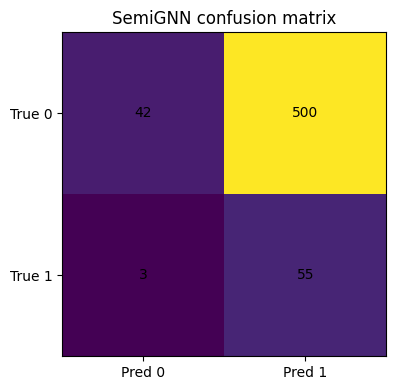

In [ ]:
!pip -q install --no-cache-dir tf-keras

import numpy as np
import scipy.sparse as sp
import tensorflow as tf

from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

from algorithms.SemiGNN.SemiGNN import SemiGNN

tf.keras.backend.clear_session()


def to_binary_labels(y_arr):
    y_arr = np.asarray(y_arr).reshape(-1)
    uniq = sorted(np.unique(y_arr).tolist())

    if set(uniq) == {1, 2}:
        return np.where(y_arr == 1, 1, 0).astype(np.int32)

    if set(uniq) <= {0, 1}:
        return y_arr.astype(np.int32)

    mapping = {uniq[0]: 0, uniq[-1]: 1}
    return np.vectorize(mapping.get)(y_arr).astype(np.int32)

def build_tf_splits(y_arr, seed=42):
    idx = np.arange(len(y_arr))
    train_idx, temp_idx = train_test_split(
        idx, train_size=TRAIN_SIZE, stratify=y_arr, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y_arr[temp_idx], random_state=seed
    )
    return train_idx.astype(np.int32), val_idx.astype(np.int32), test_idx.astype(np.int32)

def tune_threshold(y_true, probs, min_precision=0.20, beta=0.5):
    """
    Select threshold on validation set with a precision constraint.
    beta=0.5 -> F0.5, more weight on precision than recall.
    """
    best_thr = 0.5
    best_score = -1.0

    for thr in np.linspace(0.10, 0.95, 86):
        pred = (probs >= thr).astype(int)

        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if prec < min_precision:
            continue

        score = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        best_thr = 0.5
        best_score = -1.0
        for thr in np.linspace(0.10, 0.95, 86):
            pred = (probs >= thr).astype(int)
            prec = precision_score(y_true, pred, zero_division=0)
            rec = recall_score(y_true, pred, zero_division=0)
            score = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)
            if score > best_score:
                best_score = score
                best_thr = float(thr)

    return best_thr, best_score

def compute_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return out

def plot_confusion(cm, title):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

def semi_logits(model, adj_data_tf, idx_mask):
    """
    Extract logits from the original SemiGNN internals.
    """
    h1 = []
    for v in range(model.view_num):
        h = model.node_att_layer[v]([model.emb, adj_data_tf[v]])
        h = tf.reshape(h, [model.nodes, model.init_emb_size])
        h1.append(h)

    h1 = tf.concat(h1, axis=0)
    h1 = tf.reshape(h1, [model.view_num, model.nodes, model.init_emb_size])

    h2 = model.view_att_layer(h1)
    a_u = model.olp(h2)

    masked_data = tf.gather(a_u, idx_mask)
    logits = tf.matmul(masked_data, model.theta)
    return logits

def semi_forward(model, adj_data_tf, labels_onehot, idx_mask, class_weight_vec):
    logits = semi_logits(model, adj_data_tf, idx_mask)
    masked_label = tf.gather(labels_onehot, idx_mask)

    ce = tf.nn.softmax_cross_entropy_with_logits(labels=masked_label, logits=logits)
    sample_weights = tf.reduce_sum(masked_label * class_weight_vec, axis=1)
    loss = tf.reduce_mean(ce * sample_weights)

    probs = tf.nn.softmax(logits, axis=1)
    pred = tf.argmax(probs, axis=1, output_type=tf.int32)
    true = tf.argmax(masked_label, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(pred, true), tf.float32))
    return loss, acc, probs


y_bin = to_binary_labels(y)

semi_train_idx, semi_val_idx, semi_test_idx = build_tf_splits(y_bin, SEED)

adj_semi = adj.copy().astype(np.float32)
if sp.issparse(adj_semi):
    adj_semi = adj_semi + sp.eye(adj_semi.shape[0], format="csr", dtype=np.float32)
    adj_dense = adj_semi.toarray().astype(np.float32)
else:
    adj_dense = np.asarray(adj_semi, dtype=np.float32)
    np.fill_diagonal(adj_dense, 1.0)

labels_onehot = tf.convert_to_tensor(
    tf.keras.utils.to_categorical(y_bin, num_classes=2).astype(np.float32),
    dtype=tf.float32
)
adj_tf = tf.convert_to_tensor(adj_dense, dtype=tf.float32)

class SemiArgs:
    epochs = 80
    lr = 1e-3
    seed = 42
    init_emb_size = 4
    semi_encoding1 = 3
    semi_encoding2 = 2
    semi_encoding3 = 4
    alpha = 0.7
    patience = 10

args = SemiArgs()

np.random.seed(args.seed)
tf.random.set_seed(args.seed)

num_classes = 2
num_nodes = len(y_bin)

y_train = y_bin[semi_train_idx]
cw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
cw_map = {int(c): float(w) for c, w in zip([0, 1], cw)}

class_weight_vec = tf.constant([1.0, 1.0], dtype=tf.float32)

adj_data_tf = [adj_tf]


semi_model = SemiGNN(
    num_nodes,
    num_classes,
    args.semi_encoding1,
    args.semi_encoding2,
    args.semi_encoding3,
    args.init_emb_size,
    1,
    args.alpha
)

optimizer = tf.keras.optimizers.Adam(learning_rate=args.lr)

_ = semi_forward(
    semi_model, adj_data_tf, labels_onehot, semi_train_idx, class_weight_vec
)

train_vars = []
for layer in semi_model.layers:
    train_vars.extend(layer.trainable_variables)

print("Trainable vars:", len(train_vars))

best_state = None
best_val_probs = None
best_thr = 0.5
best_val_f1 = -1.0
wait = 0
best_score = -1.0


for epoch in range(args.epochs):
    with tf.GradientTape() as tape:
        loss, acc, _ = semi_forward(
            semi_model, adj_data_tf, labels_onehot, semi_train_idx, class_weight_vec
        )

    grads = tape.gradient(loss, train_vars)
    grads_and_vars = [(g, v) for g, v in zip(grads, train_vars) if g is not None]
    optimizer.apply_gradients(grads_and_vars)

    # validation
    val_loss, val_acc, val_probs = semi_forward(
        semi_model, adj_data_tf, labels_onehot, semi_val_idx, class_weight_vec
    )
    val_prob_pos = val_probs.numpy()[:, 1]
    y_val = y_bin[semi_val_idx]

    val_thr, val_f1 = tune_threshold(y_val, val_prob_pos)
    val_pr_auc = average_precision_score(y_val, val_prob_pos)
    val_thr, val_f05 = tune_threshold(y_val, val_prob_pos, min_precision=0.20, beta=0.5)

    if (epoch + 1) % 10 == 0:
        y_val_pred = (val_prob_pos >= val_thr).astype(int)
        print(
            f"epoch {epoch+1:03d} | loss={float(loss):.4f} acc={float(acc):.4f} | "
            f"val_pr_auc={val_pr_auc:.4f} val_f0.5={val_f05:.4f} thr={val_thr:.2f} "
            f"precision={precision_score(y_val, y_val_pred, zero_division=0):.4f} "
            f"recall={recall_score(y_val, y_val_pred, zero_division=0):.4f}"
        )

    if val_f05 > best_score:
      best_score = val_f05
      best_thr = val_thr
      best_state = semi_model.get_weights()
      wait = 0
    else:
      wait += 1

    if wait >= args.patience:
      print("Early stopping.")
      break

if best_state is not None:
    semi_model.set_weights(best_state)


if best_val_probs is None:
    _, _, val_probs = semi_forward(
        semi_model, adj_data_tf, labels_onehot, semi_val_idx, class_weight_vec
    )
    best_thr, best_val_f1 = tune_threshold(y_bin[semi_val_idx], val_probs.numpy()[:, 1])

test_loss, test_acc, test_probs = semi_forward(
    semi_model, adj_data_tf, labels_onehot, semi_test_idx, class_weight_vec
)
test_prob_pos = test_probs.numpy()[:, 1]
y_test = y_bin[semi_test_idx]
y_pred = (test_prob_pos >= best_thr).astype(int)

semi_metrics = compute_metrics(y_test, test_prob_pos, threshold=best_thr)
#semi_metrics["best_val_pr_auc"] = float(best_val_pr_auc)
semi_metrics["best_val_f1"] = float(best_val_f1)
semi_metrics["best_thr"] = float(best_thr)

print("SemiGNN metrics:", semi_metrics)
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plot_confusion(
    np.array([[semi_metrics["tn"], semi_metrics["fp"]],
              [semi_metrics["fn"], semi_metrics["tp"]]]),
    "SemiGNN confusion matrix"
)

In [ ]:
!grep -rl "lr=" . | xargs sed -i 's/lr=/learning_rate=/g'

In [ ]:
import numpy as np
import scipy.sparse as sp
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from algorithms.SemiGNN.SemiGNN import SemiGNN

tf.keras.backend.clear_session()

# ============================================================
# CONFIG
# ============================================================
class Args:
    epochs = 40
    lr = 1e-3
    sample_size = 3000
    seed = 42

    init_emb_size = 4
    semi_encoding1 = 3
    semi_encoding2 = 2
    semi_encoding3 = 4

    alpha = 0.7
    patience = 8

args = Args()

np.random.seed(args.seed)
tf.random.set_seed(args.seed)

# ============================================================
# HELPERS
# ============================================================
def to_1d_labels(y: np.ndarray) -> np.ndarray:
    if y.ndim == 1:
        return y.astype(np.int32).reshape(-1)
    return np.argmax(y, axis=1).astype(np.int32).reshape(-1)

def find_best_threshold(y_true, probs):
    best_thr = 0.5
    best_f1 = -1.0
    for thr in np.linspace(0.05, 0.95, 19):
        pred = (probs >= thr).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = float(thr)
    return best_thr, best_f1

def build_subgraph(adj_full, labels_raw, features, sample_size, seed):
    n_total = labels_raw.shape[0]
    sample_size = min(sample_size, n_total)

    if sample_size < n_total:
        sample_idx, _ = train_test_split(
            np.arange(n_total),
            train_size=sample_size,
            stratify=labels_raw,
            random_state=seed
        )
        sample_idx = np.array(sample_idx, dtype=np.int64)
    else:
        sample_idx = np.arange(n_total, dtype=np.int64)

    adj = adj_full[sample_idx][:, sample_idx].tocsr().astype(np.float32)
    adj = adj.maximum(adj.T)
    adj.setdiag(0)
    adj.eliminate_zeros()

    labels_sub = labels_raw[sample_idx]
    features_sub = features[sample_idx]
    return adj, labels_sub, features_sub

def forward_pass(model, feature_proj, adj_tf, features_tf, labels_onehot, idx_mask, class_weight_vec, num_nodes, init_emb_size):
    node_input = feature_proj(features_tf)  # [nodes, init_emb_size]

    h = model.node_att_layer[0]([node_input, adj_tf])
    h = tf.reshape(h, [num_nodes, init_emb_size])

    a_u = model.olp(h)

    masked_data = tf.gather(a_u, idx_mask)
    masked_label = tf.gather(labels_onehot, idx_mask)

    logits = tf.matmul(masked_data, model.theta)

    ce = tf.nn.softmax_cross_entropy_with_logits(labels=masked_label, logits=logits)
    sample_weights = tf.reduce_sum(masked_label * class_weight_vec, axis=1)
    loss = tf.reduce_mean(ce * sample_weights)

    probs = tf.nn.softmax(logits)

    pred = tf.argmax(probs, axis=1)
    true = tf.argmax(masked_label, axis=1)
    acc = tf.reduce_mean(tf.cast(tf.equal(pred, true), tf.float32))

    return loss, acc, probs

# ============================================================
# LOAD DATA
# ============================================================
print("=== LOAD DATA ===")

features = np.load("features.npy").astype(np.float32)
labels_loaded = np.load("labels.npy")

labels_raw = to_1d_labels(labels_loaded)

adj_loader = np.load("adj.npz")
adj_full = sp.csr_matrix(
    (adj_loader["data"], adj_loader["indices"], adj_loader["indptr"]),
    shape=adj_loader["shape"]
)

if features.shape[0] != labels_raw.shape[0] or adj_full.shape[0] != labels_raw.shape[0]:
    raise ValueError(
        f"Shape mismatch: features={features.shape[0]}, adj={adj_full.shape[0]}, labels={labels_raw.shape[0]}"
    )

# remove unknown labels if they exist
valid_mask = labels_raw >= 0
if not np.all(valid_mask):
    features = features[valid_mask]
    adj_full = adj_full[valid_mask][:, valid_mask]
    labels_raw = labels_raw[valid_mask]

adj, labels_raw, features = build_subgraph(adj_full=adj_full,
    labels_raw=labels_raw,
    features=features,
    sample_size=args.sample_size,
    seed=args.seed
)

num_nodes = adj.shape[0]
num_classes = int(labels_raw.max()) + 1

labels_onehot = tf.convert_to_tensor(
    tf.keras.utils.to_categorical(labels_raw, num_classes=num_classes).astype(np.float32),
    dtype=tf.float32
)

features_tf = tf.convert_to_tensor(features, dtype=tf.float32)

print(f"Nodes: {num_nodes}")
print(f"Adj shape: {adj.shape}")

# ============================================================
# SPLIT
# ============================================================
all_idx = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(
    all_idx,
    train_size=0.6,
    stratify=labels_raw,
    random_state=args.seed
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=labels_raw[temp_idx],
    random_state=args.seed
)

train_idx = tf.convert_to_tensor(np.array(train_idx, dtype=np.int32))
val_idx = tf.convert_to_tensor(np.array(val_idx, dtype=np.int32))
test_idx = tf.convert_to_tensor(np.array(test_idx, dtype=np.int32))

# ============================================================
# CLASS WEIGHTS (soft / capped)
# ============================================================
y_train = labels_raw[train_idx.numpy()]
classes = np.unique(y_train)

cw = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
cw_map = {int(c): float(w) for c, w in zip(classes, cw)}

# мягкие веса, чтобы модель не предсказывала всё как fraud
class_weight_vec = tf.constant(
    [
        1.0,
        min(cw_map.get(1, 1.0), 1.5)
    ],
    dtype=tf.float32
)

print("Class weights:", cw_map)

# ============================================================
# GRAPH
# ============================================================
adj = adj + sp.eye(num_nodes, format="csr", dtype=np.float32)
adj_dense = adj.toarray().astype(np.float32)
adj_tf = tf.convert_to_tensor(adj_dense, dtype=tf.float32)

# ============================================================
# MODEL
# ============================================================
print("Initializing SemiGNN model...")

model = SemiGNN(
    num_nodes,
    num_classes,
    args.semi_encoding1,
    args.semi_encoding2,
    args.semi_encoding3,
    args.init_emb_size,
    1,
    args.alpha
)

feature_proj = tf.keras.layers.Dense(args.init_emb_size, use_bias=False, name="feature_proj")
optimizer = tf.keras.optimizers.Adam(learning_rate=args.lr)

# warm-up build
_ = forward_pass(
    model=model,
    feature_proj=feature_proj,
    adj_tf=adj_tf,
    features_tf=features_tf,
    labels_onehot=labels_onehot,
    idx_mask=train_idx,
    class_weight_vec=class_weight_vec,
    num_nodes=num_nodes,
    init_emb_size=args.init_emb_size
)

# ============================================================
# TRAIN
# ============================================================
print("Training...")

best_val_f1 = -1.0
best_model_weights = None
best_proj_weights = None
wait = 0

train_vars = model.trainable_variables + feature_proj.trainable_variables

for epoch in range(args.epochs):
    with tf.GradientTape() as tape:
        loss, acc, _ = forward_pass(
            model=model,
            feature_proj=feature_proj,
            adj_tf=adj_tf,
            features_tf=features_tf,
            labels_onehot=labels_onehot,
            idx_mask=train_idx,
            class_weight_vec=class_weight_vec,
            num_nodes=num_nodes,
            init_emb_size=args.init_emb_size
        )

    grads = tape.gradient(loss, train_vars)
    grads_and_vars = [(g, v) for g, v in zip(grads, train_vars) if g is not None]
    optimizer.apply_gradients(grads_and_vars)

    val_loss, val_acc, val_probs = forward_pass(
        model=model,
        feature_proj=feature_proj,
        adj_tf=adj_tf,
        features_tf=features_tf,
        labels_onehot=labels_onehot,
        idx_mask=val_idx,
        class_weight_vec=class_weight_vec,
        num_nodes=num_nodes,
        init_emb_size=args.init_emb_size
    )

    y_val_true = labels_raw[val_idx.numpy()]
    val_pred = np.argmax(val_probs.numpy(), axis=1)
    val_f1 = f1_score(y_val_true, val_pred, zero_division=0)

    print(
        f"Epoch {epoch+1:02d} | "
        f"loss={float(loss):.4f} acc={float(acc):.4f} | "
        f"val_loss={float(val_loss):.4f} val_acc={float(val_acc):.4f} val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_weights = model.get_weights()
        best_proj_weights = feature_proj.get_weights()
        wait = 0
    else:
        wait += 1

    if wait >= args.patience:
        print("Early stopping")
        break

if best_model_weights is not None:
    model.set_weights(best_model_weights)
if best_proj_weights is not None:
    feature_proj.set_weights(best_proj_weights)

# ============================================================
# THRESHOLD TUNING ON VAL
# ============================================================
_, _, val_probs = forward_pass(
    model=model,
    feature_proj=feature_proj,
    adj_tf=adj_tf,
    features_tf=features_tf,
    labels_onehot=labels_onehot,
    idx_mask=val_idx,
    class_weight_vec=class_weight_vec,
    num_nodes=num_nodes,
    init_emb_size=args.init_emb_size
)

y_val_true = labels_raw[val_idx.numpy()]
val_pos_probs = val_probs.numpy()[:, 1] if num_classes == 2 else None

if num_classes == 2:
    best_thr, best_val_thr_f1 = find_best_threshold(y_val_true, val_pos_probs)
else:
    best_thr, best_val_thr_f1 = None, None

print("\nBest validation threshold:", best_thr)
print("Best validation F1 by threshold:", best_val_thr_f1)

# ============================================================
# TEST
# ============================================================
test_loss, test_acc, test_probs = forward_pass(
    model=model,
    feature_proj=feature_proj,
    adj_tf=adj_tf,
    features_tf=features_tf,
    labels_onehot=labels_onehot,
    idx_mask=test_idx,
    class_weight_vec=class_weight_vec,
    num_nodes=num_nodes,
    init_emb_size=args.init_emb_size
)

y_test_true = labels_raw[test_idx.numpy()]

if num_classes == 2:
    test_pos_probs = test_probs.numpy()[:, 1]
    y_test_pred = (test_pos_probs >= best_thr).astype(int)
else:
    test_pos_probs = None
    y_test_pred = np.argmax(test_probs.numpy(), axis=1)

print("\n=== TEST ===")
print(f"Test loss: {float(test_loss):.4f}")
print(f"Test acc:  {float(test_acc):.4f}")
if best_thr is not None:
    print(f"Threshold: {best_thr:.2f}")

print("Precision:", precision_score(y_test_true, y_test_pred, zero_division=0))
print("Recall:", recall_score(y_test_true, y_test_pred, zero_division=0))
print("F1-score:", f1_score(y_test_true, y_test_pred, zero_division=0))
print("Accuracy:", (y_test_true == y_test_pred).mean())

print("\nConfusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred, zero_division=0))

try:
    if num_classes == 2:
        print("ROC-AUC:", roc_auc_score(y_test_true, test_pos_probs))
    else:
        print("ROC-AUC:", roc_auc_score(y_test_true, test_probs.numpy(), multi_class="ovr"))
except Exception as e:
    print("ROC-AUC could not be computed:", e)

=== LOAD DATA ===
Nodes: 3000
Adj shape: (3000, 3000)
Class weights: {0: 0.5541871921182266, 1: 5.113636363636363}
Initializing SemiGNN model...
Training...
Epoch 01 | loss=0.7357 acc=0.5706 | val_loss=0.7037 val_acc=0.6100 val_f1=0.2353
Epoch 02 | loss=0.7198 acc=0.5817 | val_loss=0.6896 val_acc=0.6133 val_f1=0.2368
Epoch 03 | loss=0.7047 acc=0.5950 | val_loss=0.6762 val_acc=0.6400 val_f1=0.2552
Epoch 04 | loss=0.6904 acc=0.6061 | val_loss=0.6634 val_acc=0.6450 val_f1=0.2526
Epoch 05 | loss=0.6769 acc=0.6156 | val_loss=0.6512 val_acc=0.6600 val_f1=0.2662
Epoch 06 | loss=0.6642 acc=0.6267 | val_loss=0.6396 val_acc=0.6700 val_f1=0.2826
Epoch 07 | loss=0.6520 acc=0.6383 | val_loss=0.6286 val_acc=0.6867 val_f1=0.2985
Epoch 08 | loss=0.6405 acc=0.6511 | val_loss=0.6182 val_acc=0.6950 val_f1=0.3042
Epoch 09 | loss=0.6296 acc=0.6594 | val_loss=0.6083 val_acc=0.6983 val_f1=0.2957
Epoch 10 | loss=0.6193 acc=0.6733 | val_loss=0.5989 val_acc=0.7117 val_f1=0.3052
Epoch 11 | loss=0.6095 acc=0.6822